In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from torchvision import models
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image
from torch.utils.data import Dataset
import numpy as np
from tqdm import tqdm
import os
import glob
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import timm

# -----------------------------
# 1. 데이터 경로 및 설정
# -----------------------------
DATA_DIR = "/mnt/nas/seohan_image/seohan_data/origin"
BATCH_SIZE = 32
EPOCHS = 10
IMAGE_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 4

# -----------------------------
# 2. 클래스별 이미지 경로 수집
# -----------------------------
image_paths = []
labels = []

class_names = sorted(os.listdir(DATA_DIR))
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    for img_path in glob.glob(os.path.join(cls_path, "*.bmp")):
        image_paths.append(img_path)
        labels.append(class_to_idx[cls])

print(f"총 이미지 개수: {len(image_paths)}")
print(f"클래스 목록: {class_names}")

# -----------------------------
# 3. Stratified Split
# -----------------------------
train_paths, val_paths, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}")

# -----------------------------
# 4. Custom Dataset
# -----------------------------
class CustomImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        # Albumentations는 numpy array 사용
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)['image']

        return image, label

# -----------------------------
# 5. Albumentations 변환 정의
# -----------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = A.Compose([
    A.CenterCrop(height=min(1944, 2592), width=min(1944, 2592)),
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5
    ),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.CenterCrop(height=min(1944, 2592), width=min(1944, 2592)),
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

# -----------------------------
# 6. Dataset / DataLoader
# -----------------------------
train_dataset = CustomImageDataset(train_paths, y_train, transform=train_transforms)
val_dataset = CustomImageDataset(val_paths, y_val, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# -----------------------------
# 7. 클래스별 가중치 계산
# -----------------------------
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f"✅ Class Weights: {class_weights}")

# -----------------------------
# 8. 모델 로딩
# -----------------------------
def get_model(model_name, num_classes):
    if model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == "mobilenetv2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "mobilenetv3":
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    elif model_name == "mobilevit_s":
        model = timm.create_model('mobilevit_s', pretrained=True, num_classes=num_classes)
    elif model_name == "efficientnet_b0":
        model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=num_classes)
    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif model_name == "mobilenetv2_lite1":
        model = MobileNetV2_Lite(num_classes=num_classes, reduce_factor=0.5).to(DEVICE)
    elif model_name == "mobilenetv2_lite2":
        model = mobilenet_v2_light(num_classes=num_classes).to(DEVICE)
    elif model_name == "mobilenetv2_lite3":
        model = MobileNetV2_Custom(num_classes=num_classes).to(DEVICE)
    elif model_name == "mobilenetv2_width_mult":
        model = mobilenetv2_width_mult(num_classes=num_classes).to(DEVICE)
    elif model_name == "MobileNetV2_DepthLite":
        model = MobileNetV2_DepthLite(num_classes=num_classes).to(DEVICE)
    elif model_name == "MobileNetV2_Compact":
        model = MobileNetV2_Compact(num_classes=num_classes).to(DEVICE)
    else:
        raise ValueError(f"지원하지 않는 모델: {model_name}")

    return model.to(DEVICE)

# -----------------------------
# 9. 학습 및 검증 루프
# -----------------------------
def train_and_validate(model_name):
    model = get_model(model_name, num_classes)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    best_val_acc = 0.0
    os.makedirs("model", exist_ok=True)

    for epoch in range(EPOCHS):
        print(f"\nEpoch [{epoch+1}/{EPOCHS}] - {model_name}")

        # --- Training ---
        model.train()
        train_loss, train_correct = 0, 0
        for images, labels in tqdm(train_loader, desc="Train"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        # --- Validation ---
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Val"):
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

        # --- Save best model ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"mobilenet/{model_name}_best.pth")
            print(f"✅ Best model saved ({val_acc:.4f})")



/home/dlit/miniconda3/envs/kdh/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


총 이미지 개수: 114213
클래스 목록: ['27_30', '27_45', '28', '31']
Train: 91370, Val: 22843


/home/dlit/miniconda3/envs/kdh/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


✅ Class Weights: tensor([0.8541, 2.1541, 0.4686, 4.3320], device='cuda:0')


In [ ]:
# -----------------------------
# 7. 실행 예시
# -----------------------------
for model_name in ["densenet121", "mobilenetv2", "mobilenetv3", "resnet50", "vgg16", "mobilevit_s", "efficientnet_b0"]:
    train_and_validate(model_name)

In [17]:
train_and_validate("mobilevit_s")


Epoch [1/10] - mobilevit_s


Val: 100%|██████████| 714/714 [17:44<00:00,  1.49s/it]


Train Loss: 0.0913, Acc: 0.9770 | Val Loss: 0.0050, Acc: 0.9989
✅ Best model saved (0.9989)

Epoch [2/10] - mobilevit_s


Val: 100%|██████████| 714/714 [15:22<00:00,  1.29s/it]


Train Loss: 0.0141, Acc: 0.9964 | Val Loss: 0.0059, Acc: 0.9987

Epoch [3/10] - mobilevit_s


Val: 100%|██████████| 714/714 [16:40<00:00,  1.40s/it]


Train Loss: 0.0098, Acc: 0.9975 | Val Loss: 0.0040, Acc: 0.9988

Epoch [4/10] - mobilevit_s


Train:  18%|█▊        | 501/2856 [07:33<44:50,  1.14s/it]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [19]:
train_and_validate("efficientnet_b0")


Epoch [1/10] - efficientnet_b0


Val: 100%|██████████| 714/714 [14:46<00:00,  1.24s/it]


Train Loss: 0.0866, Acc: 0.9717 | Val Loss: 0.0097, Acc: 0.9972
✅ Best model saved (0.9972)

Epoch [2/10] - efficientnet_b0


Val: 100%|██████████| 714/714 [15:10<00:00,  1.27s/it]


Train Loss: 0.0193, Acc: 0.9941 | Val Loss: 0.0086, Acc: 0.9975
✅ Best model saved (0.9975)

Epoch [3/10] - efficientnet_b0


...

Train Loss: 0.0057, Acc: 0.9985 | Val Loss: 0.0023, Acc: 0.9993

Epoch [9/10] - efficientnet_b0


Val: 100%|██████████| 714/714 [12:24<00:00,  1.04s/it]


Train Loss: 0.0047, Acc: 0.9985 | Val Loss: 0.0017, Acc: 0.9995

Epoch [10/10] - efficientnet_b0


Val: 100%|██████████| 714/714 [13:55<00:00,  1.17s/it]

Train Loss: 0.0048, Acc: 0.9986 | Val Loss: 0.0026, Acc: 0.9992


# model 평가

In [2]:
import os
import glob
from datetime import datetime
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# --- 1. 클래스 매핑 ---
class_mapping = {
    '27_30': 0,
    '27_45': 1,
    '28': 2,
    '31': 3
}
num_classes = len(class_mapping)

# --- 2. 이미지 전처리 transform (validation/test용) ---
IMAGE_SIZE = 224
val_test_transforms = transforms.Compose([
    transforms.CenterCrop(min(1944, 2592)),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- 3. PyTorch Dataset 정의 ---
class TestDataset(Dataset):
    def __init__(self, image_paths, class_map, transform=None):
        self.image_paths = image_paths
        self.class_map = class_map
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_name = img_path.split(os.sep)[-2]  # 폴더명이 클래스 이름
        label = self.class_map[label_name]
        
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        return image, label

# --- 4. 테스트 이미지 경로 수집 ---
TEST_BASE_DIR = '/mnt/nas/seohan_image/test_data/'
test_images_filepaths = []

for folder_name in os.listdir(TEST_BASE_DIR):
    if folder_name.startswith('testdata_'):
        folder_date_str = folder_name.replace('testdata_', '')

        try:
            folder_date = datetime.strptime(folder_date_str, '%y%m%d')
            start_date = datetime.strptime('241218', '%y%m%d')
            end_date = datetime.strptime('250110', '%y%m%d')

            if start_date <= folder_date <= end_date:
                full_path = os.path.join(TEST_BASE_DIR, folder_name)
                for class_name in class_mapping.keys():
                    class_dir = os.path.join(full_path, class_name)
                    if os.path.exists(class_dir):
                        images = sorted(glob.glob(os.path.join(class_dir, '*.bmp')))
                        test_images_filepaths.extend(images)
        except ValueError:
            continue

print(f"총 {len(test_images_filepaths)}개의 테스트 이미지 수집 완료.")

# --- 5. Dataset & DataLoader 생성 ---
test_dataset = TestDataset(test_images_filepaths, class_mapping, val_test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"테스트용 DataLoader 생성 완료: {len(test_loader)} 배치")



총 56805개의 테스트 이미지 수집 완료.
테스트용 DataLoader 생성 완료: 1776 배치


In [24]:
import os
import glob
import torch
import torch.nn as nn
from torchvision import models
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
# --- 공통 설정 ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_DIR = 'model'   # 모델이 저장된 폴더
NUM_CLASSES = 4               # 클래스 개수 (수정 필요)
test_loader = test_loader     # 이미 생성된 test_loader 사용

# --- 모델 생성 함수 ---
def create_model_from_name(model_name, num_classes):
    model_name_lower = model_name.lower()

    if "vgg16" in model_name_lower:
        model = models.vgg16(weights=None)
        model.classifier[6] = nn.Linear(4096, num_classes)
    elif "densenet" in model_name_lower:
        model = models.densenet121(weights=None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif "resnet50" in model_name_lower:
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif "mobilenetv2" in model_name_lower:
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif "mobilenetv3" in model_name_lower:
        model = models.mobilenet_v3_large(weights=None)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    elif "efficientnet_b0" in model_name_lower:
        model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=num_classes)
    elif "mobilevit_s" in model_name_lower:
        # timm 라이브러리 모델
        model = timm.create_model('mobilevit_s', pretrained=False, num_classes=num_classes)

    else:
        raise ValueError(f"지원하지 않는 모델 유형입니다: {model_name}")

    return model

# --- 평가 함수 ---
def evaluate_model(model, data_loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def plot_confusion_matrix(model, test_loader, class_names, device, save_path=None, title="Confusion Matrix"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    plt.title(title)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    return cm

In [8]:
from ptflops import get_model_complexity_info

# --- 평가 실행 ---
model_files = glob.glob(os.path.join(MODEL_DIR, "*.pth"))

if not model_files:
    print(f"❌ '{MODEL_DIR}' 폴더에서 모델 파일을 찾을 수 없습니다.")
else:
    print(f"✅ {len(model_files)}개의 모델 파일을 찾았습니다.")
    model_performance = {}

    for model_path in model_files:
        model_name = os.path.basename(model_path)
        print(f"\n--- 모델 '{model_name}' 로드 및 평가 중 ---")

        try:
            # 모델 구조 복원
            model = create_model_from_name(model_name, NUM_CLASSES)
            state_dict = torch.load(model_path, map_location=DEVICE)
            model.load_state_dict(state_dict)
            model = model.to(DEVICE)

            # 파라미터 수
            total_params = sum(p.numel() for p in model.parameters())
            params_M = total_params / 1_000_000

            # 모델 파일 크기(MB)
            model_size_MB = os.path.getsize(model_path) / (1024 * 1024)

            #  FLOPs 계산 추가 
            with torch.cuda.amp.autocast(enabled=False):  
                flops, macs = get_model_complexity_info(
                    model,
                    (3, 224, 224),
                    as_strings=False,
                    print_per_layer_stat=False,
                    verbose=False
                )
            flops_G = flops / 1e9  # FLOPs를 GFLOPs로 변환

            # 모델 평가
            loss, accuracy = evaluate_model(model, test_loader, DEVICE)

            model_performance[model_name] = {
                'params_M': params_M,
                'model_size_MB': model_size_MB,
                'flops_G': flops_G,
                'loss': loss,
                'accuracy': accuracy
            }

            print(f"✅ 평가 완료: {model_name}")
            print(f"   - 파라미터: {params_M:.2f}M, 모델 크기: {model_size_MB:.2f}MB")
            print(f"   - FLOPs: {flops_G:.2f} GFLOPs")
            print(f"   - Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

        except Exception as e:
            print(f"❌ 모델 '{model_name}' 로드/평가 실패: {e}")

    # --- 결과 요약 ---
    print("\n" + "="*110)
    print("📋 전체 모델 성능 요약 (정확도 기준)")
    print("="*110)

    if model_performance:
        sorted_perf = sorted(model_performance.items(), key=lambda x: x[1]['accuracy'], reverse=True)

        print(f"{'모델 이름':<30} | {'Params(M)':>10} | {'Size(MB)':>10} | {'FLOPs(G)':>10} | {'Loss':>8} | {'Acc':>8}")
        print("-"*110)

        for name, m in sorted_perf:
            print(f"{name:<30} | {m['params_M']:>10.2f} | {m['model_size_MB']:>10.2f} | {m['flops_G']:>10.2f} | {m['loss']:>8.4f} | {m['accuracy']:>8.4f}")

    else:
        print("❌ 모든 모델에서 오류 발생")


✅ 7개의 모델 파일을 찾았습니다.

--- 모델 'vgg16_best.pth' 로드 및 평가 중 ---


/tmp/ipykernel_17288/599795126.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
                                                               

✅ 평가 완료: vgg16_best.pth
   - 파라미터: 134.28M, 모델 크기: 512.24MB
   - FLOPs: 15.52 GFLOPs
   - Loss: 0.2337, Accuracy: 0.9247

--- 모델 'efficientnet_b0_best.pth' 로드 및 평가 중 ---


✅ 평가 완료: efficientnet_b0_best.pth
   - 파라미터: 4.01M, 모델 크기: 15.59MB
   - FLOPs: 0.39 GFLOPs
   - Loss: 0.0195, Accuracy: 0.9946

--- 모델 'resnet50_best.pth' 로드 및 평가 중 ---


✅ 평가 완료: resnet50_best.pth
   - 파라미터: 23.52M, 모델 크기: 90.01MB
   - FLOPs: 4.13 GFLOPs
   - Loss: 0.0041, Accuracy: 0.9994

--- 모델 'densenet121_best.pth' 로드 및 평가 중 ---


✅ 평가 완료: densenet121_best.pth
   - 파라미터: 6.96M, 모델 크기: 27.13MB
   - FLOPs: 2.90 GFLOPs
   - Loss: 0.0094, Accuracy: 0.9976

--- 모델 'mobilevit_s_best.pth' 로드 및 평가 중 ---


✅ 평가 완료: mobilevit_s_best.pth
   - 파라미터: 4.94M, 모델 크기: 19.01MB
   - FLOPs: 1.24 GFLOPs
   - Loss: 0.0088, Accuracy: 0.9974

--- 모델 'mobilenetv3_best.pth' 로드 및 평가 중 ---


✅ 평가 완료: mobilenetv3_best.pth
   - 파라미터: 4.21M, 모델 크기: 16.25MB
   - FLOPs: 0.23 GFLOPs
   - Loss: 0.0403, Accuracy: 0.9891

--- 모델 'mobilenetv2_best.pth' 로드 및 평가 중 ---


✅ 평가 완료: mobilenetv2_best.pth
   - 파라미터: 2.23M, 모델 크기: 8.74MB
   - FLOPs: 0.32 GFLOPs
   - Loss: 0.0162, Accuracy: 0.9954

📋 전체 모델 성능 요약 (정확도 기준)
모델 이름                          |  Params(M) |   Size(MB) |   FLOPs(G) |     Loss |      Acc
--------------------------------------------------------------------------------------------------------------
resnet50_best.pth              |      23.52 |      90.01 |       4.13 |   0.0041 |   0.9994
densenet121_best.pth           |       6.96 |      27.13 |       2.90 |   0.0094 |   0.9976
mobilevit_s_best.pth           |       4.94 |      19.01 |       1.24 |   0.0088 |   0.9974
mobilenetv2_best.pth           |       2.23 |       8.74 |       0.32 |   0.0162 |   0.9954
efficientnet_b0_best.pth       |       4.01 |      15.59 |       0.39 |   0.0195 |   0.9946
mobilenetv3_best.pth           |       4.21 |      16.25 |       0.23 |   0.0403 |   0.9891
vgg16_best.pth                 |     134.28 |     512.24 |      15.52 |   0.2337 |   0.9247


In [9]:
def clean_model_name(model_name: str) -> str:
    name = model_name.replace(".pth", "")
    name = name.replace("_best", "")
    return name

import matplotlib.pyplot as plt
import numpy as np

def plot_bubble_chart(model_perf, save_path="bubble_chart.png"):
    names, flops, accs, sizes, params = [], [], [], [], []

    for model_name, info in model_perf.items():
        names.append(clean_model_name(model_name))
        flops.append(info['flops_G'])
        accs.append(info['accuracy'])
        sizes.append(info['model_size_MB'])
        params.append(info['params_M'])

    flops = np.array(flops)
    accs = np.array(accs)
    sizes = np.array(sizes)
    params = np.array(params)

    # 버블 크기 확대 (가독성)
    bubble_size = sizes * 20

    plt.figure(figsize=(12, 8))

    scatter = plt.scatter(
        flops, accs,
        s=bubble_size,
        c=params,          # 파라미터 수로 색상 변경
        cmap='viridis',
        alpha=0.75,
        edgecolors='black'
    )

    plt.colorbar(scatter, label="Parameters (M)")
    plt.xlabel("FLOPs (GFLOPs)")
    plt.ylabel("Accuracy")
    plt.title("Model Comparison: FLOPs vs Accuracy (Bubble = Model Size MB)")

    # 라벨 표시
    for i, name in enumerate(names):
        plt.text(flops[i] * 1.01, accs[i] * 0.999, name, fontsize=9)

    plt.grid(True, linestyle='--', alpha=0.4)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()


def plot_comparison_charts(model_perf, save_path="comparison_charts.png"):
    names = [clean_model_name(k) for k in model_perf.keys()]
    accs = [v['accuracy'] for v in model_perf.values()]
    flops = [v['flops_G'] for v in model_perf.values()]
    params = [v['params_M'] for v in model_perf.values()]

    plt.figure(figsize=(18, 6))

    # ---- Accuracy ----
    plt.subplot(1, 3, 1)
    plt.bar(names, accs)
    plt.xticks(rotation=45, ha='right')
    plt.title("Model Accuracy")
    plt.ylabel("Accuracy")

    # ---- FLOPs ----
    plt.subplot(1, 3, 2)
    plt.bar(names, flops)
    plt.xticks(rotation=45, ha='right')
    plt.title("Model FLOPs (G)")

    # ---- Params ----
    plt.subplot(1, 3, 3)
    plt.bar(names, params)
    plt.xticks(rotation=45, ha='right')
    plt.title("Model Parameters (M)")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()


In [14]:
if "mobilenetv3_best.pth" in model_performance:
    del model_performance["mobilenetv3_best.pth"]
model_performance

{'vgg16_best.pth': {'params_M': 134.276932,
  'model_size_MB': 512.2373552322388,
  'flops_G': 15.519144964,
  'loss': 0.23369353723544778,
  'accuracy': 0.9247249361851949},
 'efficientnet_b0_best.pth': {'params_M': 4.012672,
  'model_size_MB': 15.592595100402832,
  'flops_G': 0.390832572,
  'loss': 0.01949927944436376,
  'accuracy': 0.9945955461667106},
 'resnet50_best.pth': {'params_M': 23.516228,
  'model_size_MB': 90.01242351531982,
  'flops_G': 4.130396164,
  'loss': 0.004067264654749592,
  'accuracy': 0.9994190652231317},
 'densenet121_best.pth': {'params_M': 6.957956,
  'model_size_MB': 27.12575340270996,
  'flops_G': 2.898822148,
  'loss': 0.009418595047467938,
  'accuracy': 0.9975530323034945},
 'mobilevit_s_best.pth': {'params_M': 4.940196,
  'model_size_MB': 19.011343002319336,
  'flops_G': 1.244887444,
  'loss': 0.008769552760629589,
  'accuracy': 0.9974474077986093},
 'mobilenetv2_best.pth': {'params_M': 2.228996,
  'model_size_MB': 8.73902416229248,
  'flops_G': 0.319024

In [16]:
# 1) mobilenetv3 제거
if "mobilenetv3_best.pth" in model_performance:
    del model_performance["mobilenetv3_best.pth"]

# 2) 그래프 생성
plot_bubble_chart(model_performance, save_path="result_bubble_chart.png")
plot_comparison_charts(model_performance, save_path="result_comparison_charts.png")


총 6개 모델 평가 시작!
model_name efficientnet_b0_best.pth


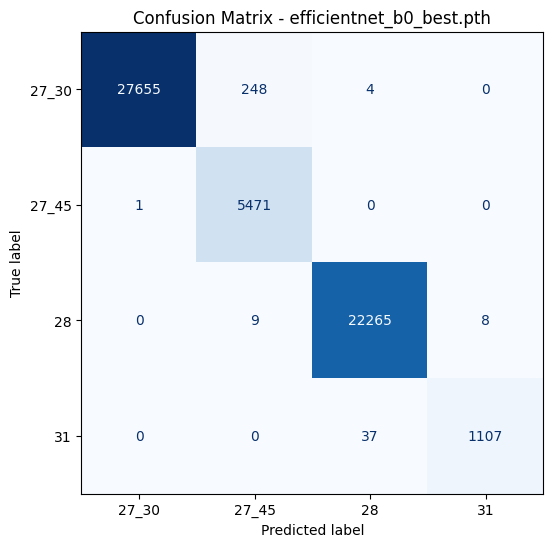

model_name resnet50_best.pth


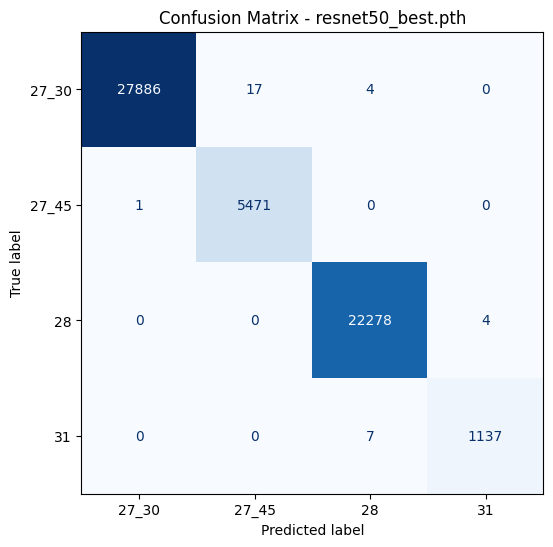

model_name densenet121_best.pth


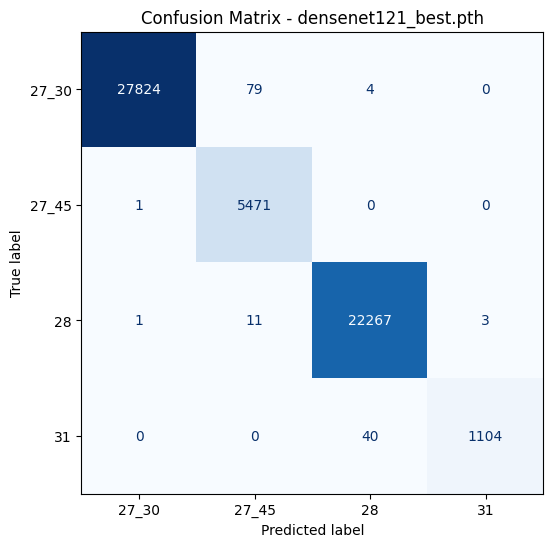

model_name mobilevit_s_best.pth


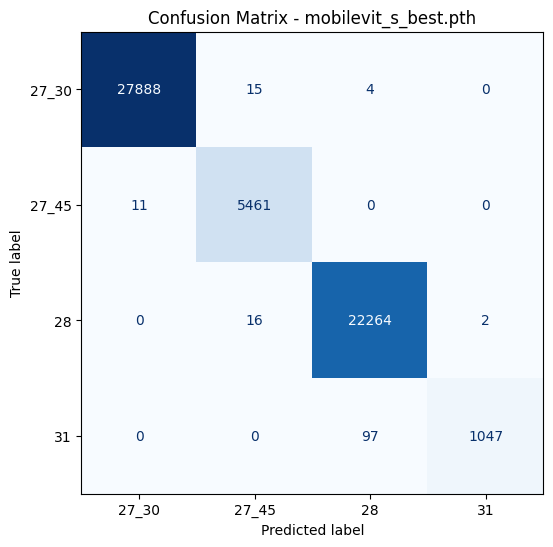

model_name mobilenetv3_best.pth


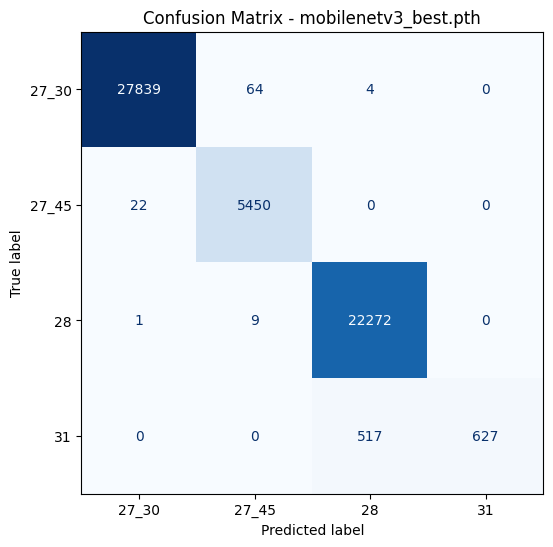

model_name mobilenetv2_best.pth


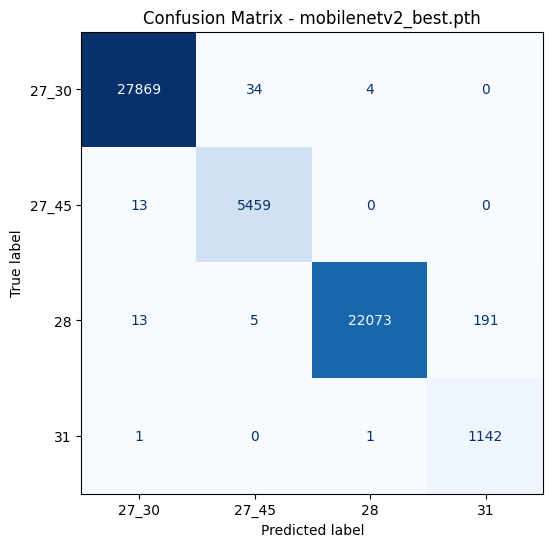

In [3]:
MODEL_DIR = 'model'
model_files = glob.glob(os.path.join(MODEL_DIR, "*.pth"))

class_names = ["27_30", "27_45", "28", "31"]
NUM_CLASSES = 4
def load_model(model_path):
    model_name = os.path.basename(model_path)
    model = create_model_from_name(model_name, NUM_CLASSES)  # 사용 중인 모델 생성 함수
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    return model
    
if not model_files:
    print("❌ 모델 파일 없음")
else:
    print(f"총 {len(model_files)}개 모델 평가 시작!")
    model_performance = {}

    for model_path in model_files:
        model_name = os.path.basename(model_path)
        print('model_name', model_name)
        try:
            model = create_model_from_name(model_name, NUM_CLASSES)
            state_dict = torch.load(model_path, map_location=DEVICE)
            model.load_state_dict(state_dict)
            model.to(DEVICE)

            save_path = f"./results/confusion_matrix_{model_name.replace('.pth', '')}.png"
        
            plot_confusion_matrix(
                model,
                test_loader,
                class_names,
                DEVICE,
                save_path=save_path,
                title=f"Confusion Matrix - {model_name}"
            )

        except Exception as e:
            print(f"❌ 오류: {e}")



### 경량화

In [3]:
import os
import glob
import torch
import torch.nn as nn
from torchvision import models
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from ptflops import get_model_complexity_info

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_DIR = 'mobilenet'
NUM_CLASSES = 4

# (1) Width Multiplier 축소
def mobilenetv2_width_mult(num_classes=4, width_mult=0.5):
    model = models.mobilenet_v2(weights=None, width_mult=width_mult)
    model.classifier[1] = nn.Linear(model.last_channel, num_classes)
    return model

# (2) Depth 축소
class MobileNetV2_DepthLite(nn.Module):
    def __init__(self, num_classes=4, remove_last_blocks=3):
        super().__init__()
        base_model = models.mobilenet_v2(weights=None)
        self.features = nn.Sequential(
            *list(base_model.features.children())[:-remove_last_blocks]
        )

        dummy = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            out_c = self.features(dummy).shape[1]

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(out_c, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        x = self.classifier(x)
        return x

# (3) Compact (Width + Depth)
class MobileNetV2_Compact(nn.Module):
    def __init__(self, num_classes=4, width_mult=0.5, remove_last_blocks=3):
        super().__init__()
        base_model = models.mobilenet_v2(weights=None, width_mult=width_mult)
        self.features = nn.Sequential(
            *list(base_model.features.children())[:-remove_last_blocks]
        )

        dummy = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            out_c = self.features(dummy).shape[1]

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(out_c, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        x = self.classifier(x)
        return x

# ============================
# 모델 생성 함수 (여기에 추가!)
# ============================

def create_lightWweightModel_from_name(model_name, num_classes):
    name = model_name.lower()

    # ---- α 모델들 ----
    if "mobilenetv2_alpha1.0" in name:
        model = models.mobilenet_v2(weights=None, width_mult=1.0)
    elif "mobilenetv2_alpha0.75" in name:
        model = models.mobilenet_v2(weights=None, width_mult=0.75)
    elif "mobilenetv2_alpha0.5" in name:
        model = models.mobilenet_v2(weights=None, width_mult=0.5)
    elif "mobilenetv2_alpha0.25" in name:
        model = models.mobilenet_v2(weights=None, width_mult=0.25)

    # ---- Width Multiplier Custom ----
    elif "mobilenetv2_width_mult" in name:
        model = mobilenetv2_width_mult(num_classes=num_classes, width_mult=0.5)

    # ---- DepthLite ----
    elif "mobilenetv2_depthlite" in name:
        model = MobileNetV2_DepthLite(num_classes=num_classes)

    # ---- Compact ----
    elif "mobilenetv2_compact" in name:
        model = MobileNetV2_Compact(num_classes=num_classes, width_mult=0.5)

    else:
        raise ValueError(f"지원하지 않는 모델 이름입니다: {model_name}")

    # 마지막 FC 수정
    if hasattr(model, "classifier"):
        last_layer = model.classifier

        # Case 1: Sequential 형태
        if isinstance(last_layer, nn.Sequential):
            # 마지막 Linear 찾기
            for i in reversed(range(len(last_layer))):
                if isinstance(last_layer[i], nn.Linear):
                    in_features = last_layer[i].in_features
                    last_layer[i] = nn.Linear(in_features, num_classes)
                    break

        # Case 2: classifier 자체가 Linear
        elif isinstance(last_layer, nn.Linear):
            in_features = last_layer.in_features
            model.classifier = nn.Linear(in_features, num_classes)

    # 3) mobilenetv1 / custom 등 일부는 fc를 따로 가질 수도 있음
    elif hasattr(model, "fc"):
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    else:
        raise ValueError("Cannot find classifier or fc layer to replace!")

    return model

# ============================
# 평가 함수
# ============================

def evaluate_model(model, data_loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total



def plot_confusion_matrix(model, test_loader, class_names, device, save_path=None, title="Confusion Matrix"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    plt.title(title)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    return cm

In [ ]:
# ============================
# 테스트 실행
# ============================
MODEL_DIR = 'mobilenet'
model_files = glob.glob(os.path.join(MODEL_DIR, "*.pth"))

if not model_files:
    print("❌ 모델 파일 없음")
else:
    print(f"총 {len(model_files)}개 모델 평가 시작!")
    model_performance = {}

    for model_path in model_files:
        model_name = os.path.basename(model_path)
        print(f"\n▶ 모델 평가 중: {model_name}")

        try:
            model = create_lightWweightModel_from_name(model_name, NUM_CLASSES)
            state_dict = torch.load(model_path, map_location=DEVICE)
            model.load_state_dict(state_dict)
            model.to(DEVICE)

             # 파라미터 수
            total_params = sum(p.numel() for p in model.parameters())
            params_M = total_params / 1_000_000

            # 모델 파일 크기(MB)
            model_size_MB = os.path.getsize(model_path) / (1024 * 1024)

            #  FLOPs 계산 추가 
            with torch.cuda.amp.autocast(enabled=False):  
                flops, macs = get_model_complexity_info(
                    model,
                    (3, 224, 224),
                    as_strings=False,
                    print_per_layer_stat=False,
                    verbose=False
                )
            flops_G = flops / 1e9  # FLOPs를 GFLOPs로 변환

            # 모델 평가
            loss, accuracy = evaluate_model(model, test_loader, DEVICE)

            model_performance[model_name] = {
                'params_M': params_M,
                'model_size_MB': model_size_MB,
                'flops_G': flops_G,
                'loss': loss,
                'accuracy': accuracy
            }

            print(f"✅ 평가 완료: {model_name}")
            print(f"   - 파라미터: {params_M:.2f}M, 모델 크기: {model_size_MB:.2f}MB")
            print(f"   - FLOPs: {flops_G:.2f} GFLOPs")
            print(f"   - Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

        except Exception as e:
            print(f"❌ 모델 '{model_name}' 로드/평가 실패: {e}")
            

    if model_performance:
        sorted_perf = sorted(model_performance.items(), key=lambda x: x[1]['accuracy'], reverse=True)

        print(f"{'모델 이름':<30} | {'Params(M)':>10} | {'Size(MB)':>10} | {'FLOPs(G)':>10} | {'Loss':>8} | {'Acc':>8}")
        print("-"*110)

        for name, m in sorted_perf:
            print(f"{name:<30} | {m['params_M']:>10.2f} | {m['model_size_MB']:>10.2f} | {m['flops_G']:>10.2f} | {m['loss']:>8.4f} | {m['accuracy']:>8.4f}")

    else:
        print("❌ 모든 모델에서 오류 발생")



총 4개 모델 평가 시작!

▶ 모델 평가 중: mobilenetv2_alpha0.25_best.pth


/tmp/ipykernel_1098131/725249621.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Evaluating:  63%|██████▎   | 1117/1776 [32:50<20:30,  1.87s/it]

In [5]:
model_performance

{'mobilenetv2_alpha0.25_best.pth': {'params_M': 0.243236,
  'model_size_MB': 1.0758771896362305,
  'flops_G': 0.042617092,
  'loss': 0.7393157876667953,
  'accuracy': 0.5828184138720183},
 'mobilenetv2_alpha1.0_best.pth': {'params_M': 2.228996,
  'model_size_MB': 8.74183177947998,
  'flops_G': 0.319024132,
  'loss': 0.07112742280367162,
  'accuracy': 0.9742276208080275},
 'mobilenetv2_alpha0.5_best.pth': {'params_M': 0.692804,
  'model_size_MB': 2.8223371505737305,
  'flops_G': 0.106528772,
  'loss': 0.03990286311065653,
  'accuracy': 0.9882404717894552},
 'mobilenetv2_alpha0.75_best.pth': {'params_M': 1.360548,
  'model_size_MB': 5.3993635177612305,
  'flops_G': 0.2249065,
  'loss': 0.07690717012338447,
  'accuracy': 0.9764809435789104}}

In [6]:
if model_performance:
    sorted_perf = sorted(model_performance.items(), key=lambda x: x[1]['accuracy'], reverse=True)

    print(f"{'모델 이름':<30} | {'Params(M)':>10} | {'Size(MB)':>10} | {'FLOPs(G)':>10} | {'Loss':>8} | {'Acc':>8}")
    print("-"*110)

    for name, m in sorted_perf:
        print(f"{name:<30} | {m['params_M']:>10.2f} | {m['model_size_MB']:>10.2f} | {m['flops_G']:>10.2f} | {m['loss']:>8.4f} | {m['accuracy']:>8.4f}")

else:
    print("❌ 모든 모델에서 오류 발생")


모델 이름                          |  Params(M) |   Size(MB) |   FLOPs(G) |     Loss |      Acc
--------------------------------------------------------------------------------------------------------------
mobilenetv2_alpha0.5_best.pth  |       0.69 |       2.82 |       0.11 |   0.0399 |   0.9882
mobilenetv2_alpha0.75_best.pth |       1.36 |       5.40 |       0.22 |   0.0769 |   0.9765
mobilenetv2_alpha1.0_best.pth  |       2.23 |       8.74 |       0.32 |   0.0711 |   0.9742
mobilenetv2_alpha0.25_best.pth |       0.24 |       1.08 |       0.04 |   0.7393 |   0.5828


In [7]:
if model_performance:
    sorted_perf = sorted(model_performance.items(), key=lambda x: x[1]['accuracy'], reverse=True)

    print(f"{'모델 이름':<30} | {'Params(M)':>10} | {'Size(MB)':>10} | {'FLOPs(G)':>10} | {'Loss':>8} | {'Acc':>8}")
    print("-"*110)

    for name, m in sorted_perf:
        print(f"{name:<30} | {m['params_M']:>10.2f} | {m['model_size_MB']:>10.2f} | {m['flops_G']:>10.2f} | {m['loss']:>8.4f} | {m['accuracy']:>8.4f}")

else:
    print("❌ 모든 모델에서 오류 발생")


모델 이름                          |  Params(M) |   Size(MB) |   FLOPs(G) |     Loss |      Acc
--------------------------------------------------------------------------------------------------------------
mobilenetv2_alpha1.0_best.pth  |       2.23 |       8.74 |       0.32 |   0.0232 |   0.9925
MobileNetV2_DepthLite_best.pth |       1.02 |       4.07 |       0.26 |   0.0323 |   0.9899
mobilenetv2_alpha0.75_best.pth |       1.36 |       5.40 |       0.22 |   0.0486 |   0.9839
mobilenetv2_width_mult_best.pth |       0.69 |       2.82 |       0.11 |   0.1346 |   0.9636
MobileNetV2_Compact_best.pth   |       0.28 |       1.19 |       0.09 |   0.1780 |   0.9311
mobilenetv2_alpha0.5_best.pth  |       0.69 |       2.82 |       0.11 |   0.2911 |   0.9107
mobilenetv2_alpha0.25_best.pth |       0.24 |       1.08 |       0.04 |   0.5268 |   0.7757


In [7]:
model_performance_light = {
    'mobilenetv2_alpha1.0_best.pth': {
        'params_M': 2.23,
        'model_size_MB': 8.74,
        'flops_G': 0.32,
        'loss': 0.0232,
        'accuracy': 0.9925
    },
    'MobileNetV2_DepthLite_best.pth': {
        'params_M': 1.02,
        'model_size_MB': 4.07,
        'flops_G': 0.26,
        'loss': 0.0323,
        'accuracy': 0.9899
    },
    'mobilenetv2_alpha0.75_best.pth': {
        'params_M': 1.36,
        'model_size_MB': 5.40,
        'flops_G': 0.22,
        'loss': 0.0486,
        'accuracy': 0.9839
    },
    'mobilenetv2_width_mult_best.pth': {
        'params_M': 0.69,
        'model_size_MB': 2.82,
        'flops_G': 0.11,
        'loss': 0.1346,
        'accuracy': 0.9636
    },
    'MobileNetV2_Compact_best.pth': {
        'params_M': 0.28,
        'model_size_MB': 1.19,
        'flops_G': 0.09,
        'loss': 0.1780,
        'accuracy': 0.9311
    },
    'mobilenetv2_alpha0.5_best.pth': {
        'params_M': 0.69,
        'model_size_MB': 2.82,
        'flops_G': 0.11,
        'loss': 0.2911,
        'accuracy': 0.9107
    },
    'mobilenetv2_alpha0.25_best.pth': {
        'params_M': 0.24,
        'model_size_MB': 1.08,
        'flops_G': 0.04,
        'loss': 0.5268,
        'accuracy': 0.7757
    }
}

총 7개 모델 평가 시작!
model_name mobilenetv2_width_mult_best.pth


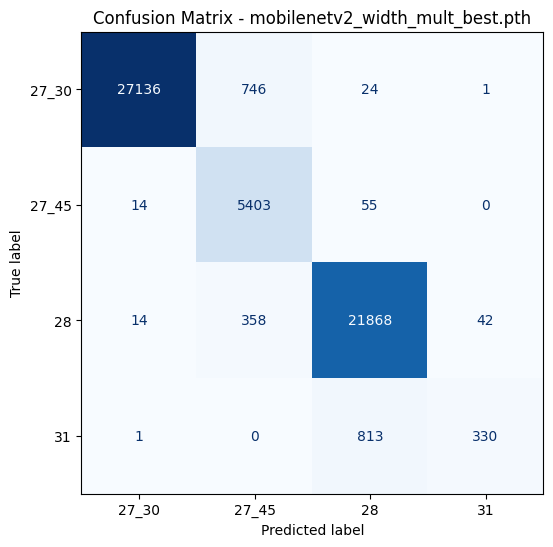

model_name MobileNetV2_DepthLite_best.pth


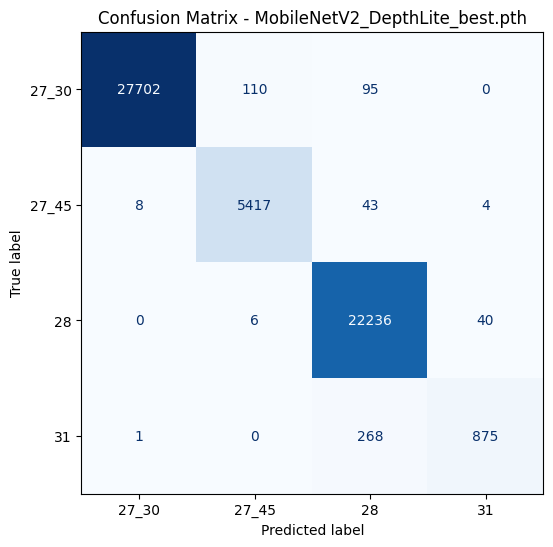

model_name mobilenetv2_alpha0.25_best.pth


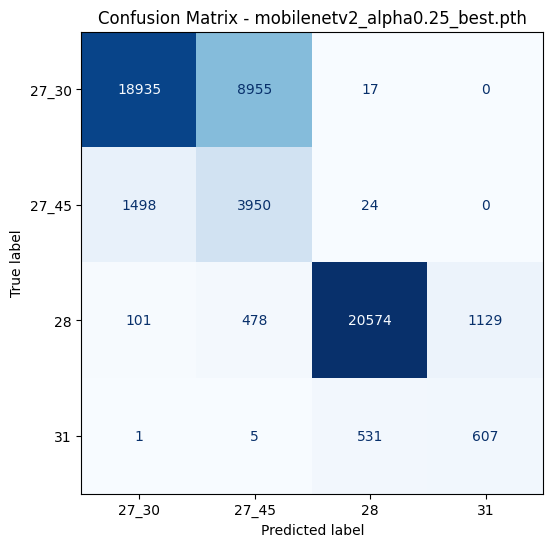

model_name mobilenetv2_alpha1.0_best.pth


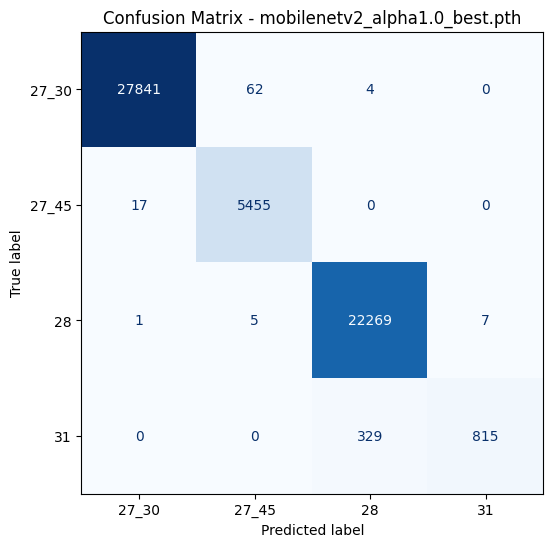

model_name mobilenetv2_alpha0.5_best.pth


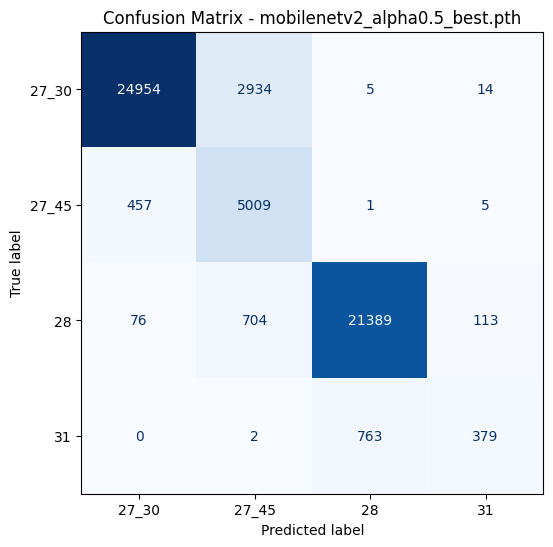

model_name mobilenetv2_alpha0.75_best.pth


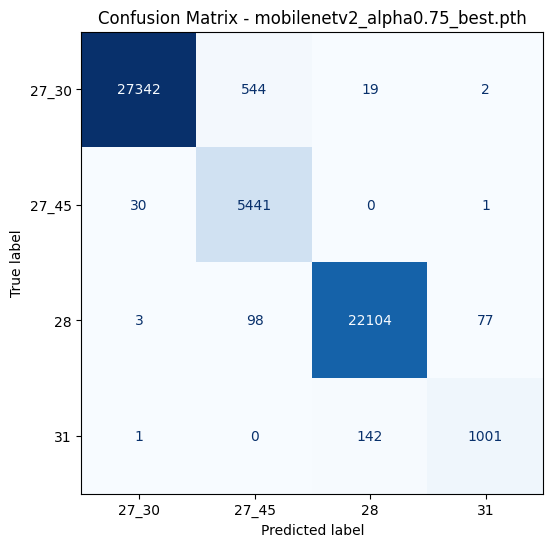

model_name MobileNetV2_Compact_best.pth


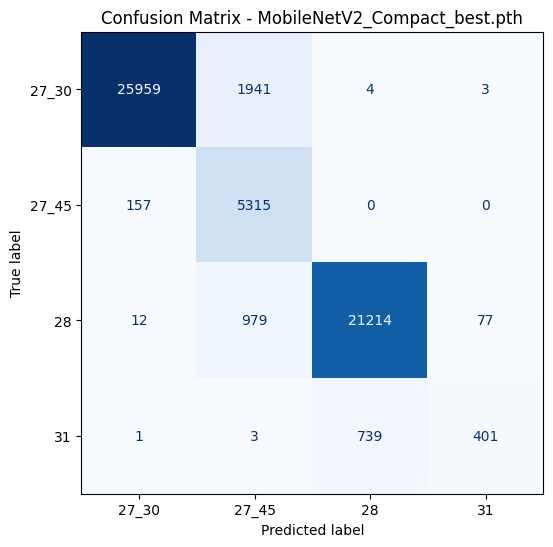

In [8]:
model_files = glob.glob(os.path.join(MODEL_DIR, "*.pth"))

class_names = ["27_30", "27_45", "28", "31"]
NUM_CLASSES = 4
def load_model(model_path):
    model_name = os.path.basename(model_path)
    model = create_model_from_name(model_name, NUM_CLASSES)  # 사용 중인 모델 생성 함수
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    return model
    
if not model_files:
    print("❌ 모델 파일 없음")
else:
    print(f"총 {len(model_files)}개 모델 평가 시작!")
    model_performance = {}

    for model_path in model_files:
        model_name = os.path.basename(model_path)
        print('model_name', model_name)
        try:
            model = create_lightWweightModel_from_name(model_name, NUM_CLASSES)
            state_dict = torch.load(model_path, map_location=DEVICE)
            model.load_state_dict(state_dict)
            model.to(DEVICE)

            save_path = f"./results/lightModel2/confusion_matrix_{model_name.replace('.pth', '')}.png"
        
            plot_confusion_matrix(
                model,
                test_loader,
                class_names,
                DEVICE,
                save_path=save_path,
                title=f"Confusion Matrix - {model_name}"
            )

        except Exception as e:
            print(f"❌ 오류: {e}")



In [ ]:
# 2) 경량 모델 그래프 생성
plot_bubble_chart(model_performance_light, save_path="results/result_bubble_chart.png")
plot_comparison_charts(model_performance_light, save_path="results/result_comparison_charts.png")


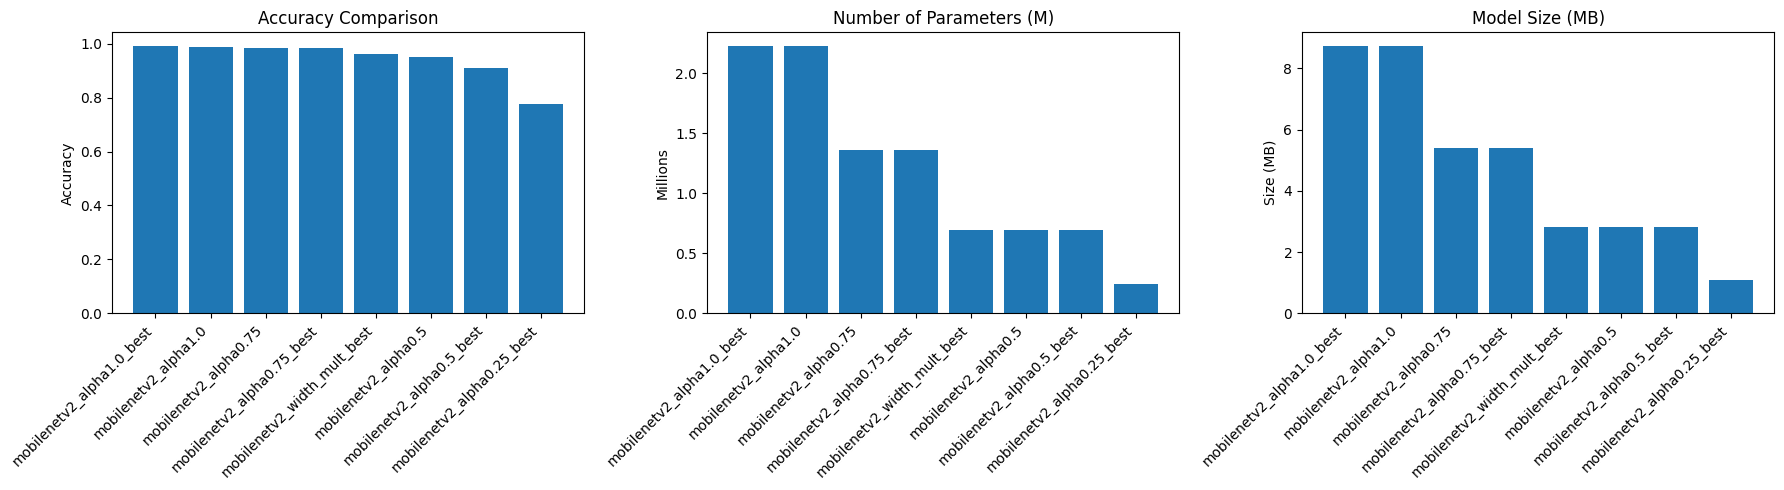


📄 Markdown Table

| Model | Accuracy | Params (M) | Size (MB) |
|---|---|---|---|
| mobilenetv2_alpha1.0_best | 0.9925 | 2.23 | 8.74 |
| mobilenetv2_alpha1.0 | 0.9892 | 2.23 | 8.74 |
| mobilenetv2_alpha0.75 | 0.9839 | 1.36 | 5.40 |
| mobilenetv2_alpha0.75_best | 0.9839 | 1.36 | 5.40 |
| mobilenetv2_width_mult_best | 0.9636 | 0.69 | 2.82 |
| mobilenetv2_alpha0.5 | 0.9508 | 0.69 | 2.82 |
| mobilenetv2_alpha0.5_best | 0.9107 | 0.69 | 2.82 |
| mobilenetv2_alpha0.25_best | 0.7757 | 0.24 | 1.08 |

📄 LaTeX Table

\begin{table}[h]
\centering
\begin{tabular}{lccc}
\hline
Model & Accuracy & Params (M) & Size (MB) \\
\hline
mobilenetv2_alpha1.0_best & 0.9925 & 2.23 & 8.74 \\
mobilenetv2_alpha1.0 & 0.9892 & 2.23 & 8.74 \\
mobilenetv2_alpha0.75 & 0.9839 & 1.36 & 5.40 \\
mobilenetv2_alpha0.75_best & 0.9839 & 1.36 & 5.40 \\
mobilenetv2_width_mult_best & 0.9636 & 0.69 & 2.82 \\
mobilenetv2_alpha0.5 & 0.9508 & 0.69 & 2.82 \\
mobilenetv2_alpha0.5_best & 0.9107 & 0.69 & 2.82 \\
mobilenetv2_alpha0.25_bes

'\\begin{table}[h]\n\\centering\n\\begin{tabular}{lccc}\n\\hline\nModel & Accuracy & Params (M) & Size (MB) \\\\\n\\hline\nmobilenetv2_alpha1.0_best & 0.9925 & 2.23 & 8.74 \\\\\nmobilenetv2_alpha1.0 & 0.9892 & 2.23 & 8.74 \\\\\nmobilenetv2_alpha0.75 & 0.9839 & 1.36 & 5.40 \\\\\nmobilenetv2_alpha0.75_best & 0.9839 & 1.36 & 5.40 \\\\\nmobilenetv2_width_mult_best & 0.9636 & 0.69 & 2.82 \\\\\nmobilenetv2_alpha0.5 & 0.9508 & 0.69 & 2.82 \\\\\nmobilenetv2_alpha0.5_best & 0.9107 & 0.69 & 2.82 \\\\\nmobilenetv2_alpha0.25_best & 0.7757 & 0.24 & 1.08 \\\\\n\\hline\n\\end{tabular}\n\\caption{Performance comparison of MobileNetV2 variants}\n\\end{table}'

In [17]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1) 너가 제공한 모델 성능 데이터
# ---------------------------------------------------------
model_performance = {
    "mobilenetv2_alpha1.0_best":   {"accuracy": 0.9925, "params_M": 2.23, "model_size_MB": 8.74},
    "mobilenetv2_alpha1.0":        {"accuracy": 0.9892, "params_M": 2.23, "model_size_MB": 8.74},
    "mobilenetv2_alpha0.75":       {"accuracy": 0.9839, "params_M": 1.36, "model_size_MB": 5.40},
    "mobilenetv2_alpha0.75_best":  {"accuracy": 0.9839, "params_M": 1.36, "model_size_MB": 5.40},
    "mobilenetv2_width_mult_best": {"accuracy": 0.9636, "params_M": 0.69, "model_size_MB": 2.82},
    "mobilenetv2_alpha0.5":        {"accuracy": 0.9508, "params_M": 0.69, "model_size_MB": 2.82},
    "mobilenetv2_alpha0.5_best":   {"accuracy": 0.9107, "params_M": 0.69, "model_size_MB": 2.82},
    "mobilenetv2_alpha0.25_best":  {"accuracy": 0.7757, "params_M": 0.24, "model_size_MB": 1.08},
}

# ---------------------------------------------------------
# 2) 그래프 그리기 함수
# ---------------------------------------------------------
def plot_model_comparison(model_performance):

    names = list(model_performance.keys())
    acc = [v["accuracy"] for v in model_performance.values()]
    params = [v["params_M"] for v in model_performance.values()]
    size = [v["model_size_MB"] for v in model_performance.values()]

    plt.figure(figsize=(18, 5))

    # Accuracy
    plt.subplot(1, 3, 1)
    plt.bar(names, acc)
    plt.title("Accuracy Comparison")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=45, ha='right')

    # Params
    plt.subplot(1, 3, 2)
    plt.bar(names, params)
    plt.title("Number of Parameters (M)")
    plt.ylabel("Millions")
    plt.xticks(rotation=45, ha='right')

    # Model Size
    plt.subplot(1, 3, 3)
    plt.bar(names, size)
    plt.title("Model Size (MB)")
    plt.ylabel("Size (MB)")
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# 3) Markdown 표 출력
# ---------------------------------------------------------
def generate_markdown_table(model_performance):

    header = "| Model | Accuracy | Params (M) | Size (MB) |"
    line = "|---|---|---|---|"
    rows = []

    for name, m in model_performance.items():
        rows.append(f"| {name} | {m['accuracy']:.4f} | {m['params_M']:.2f} | {m['model_size_MB']:.2f} |")

    table = "\n".join([header, line] + rows)

    print("\n📄 Markdown Table\n")
    print(table)
    return table


# ---------------------------------------------------------
# 4) LaTeX 표 생성 (논문용)
# ---------------------------------------------------------
def generate_latex_table(model_performance):

    latex = "\\begin{table}[h]\n\\centering\n"
    latex += "\\begin{tabular}{lccc}\n"
    latex += "\\hline\n"
    latex += "Model & Accuracy & Params (M) & Size (MB) \\\\\n"
    latex += "\\hline\n"

    for name, m in model_performance.items():
        latex += f"{name} & {m['accuracy']:.4f} & {m['params_M']:.2f} & {m['model_size_MB']:.2f} \\\\\n"

    latex += "\\hline\n"
    latex += "\\end{tabular}\n"
    latex += "\\caption{Performance comparison of MobileNetV2 variants}\n"
    latex += "\\end{table}"

    print("\n📄 LaTeX Table\n")
    print(latex)
    return latex


# ---------------------------------------------------------
# 5) 실행
# ---------------------------------------------------------
plot_model_comparison(model_performance)
generate_markdown_table(model_performance)
generate_latex_table(model_performance)

# ---------------------------------------------------------
# (선택) Confusion Matrix & ROC는 기존 코드 그대로 호출
# cm = plot_confusion_matrix(model, test_loader, ["27_30", "27_45", "28", "31"], DEVICE)
# plot_multiclass_roc(model, test_loader, NUM_CLASSES, DEVICE)
# ---------------------------------------------------------


In [8]:
for name, info in sorted_models:
    print(f"{name:<35} | Acc {info['accuracy']:.4f} | Params {info['params_M']:.2f}M | Size {info['size_MB']:.2f}MB")


mobilenetv2_alpha1.0_best.pth       | Acc 0.9925 | Params 2.23M | Size 8.74MB
mobilenetv2_alpha1.0.pth            | Acc 0.9892 | Params 2.23M | Size 8.74MB
mobilenetv2_alpha0.75.pth           | Acc 0.9839 | Params 1.36M | Size 5.40MB
mobilenetv2_alpha0.75_best.pth      | Acc 0.9839 | Params 1.36M | Size 5.40MB
mobilenetv2_width_mult_best.pth     | Acc 0.9636 | Params 0.69M | Size 2.82MB
mobilenetv2_alpha0.5.pth            | Acc 0.9508 | Params 0.69M | Size 2.82MB
mobilenetv2_alpha0.5_best.pth       | Acc 0.9107 | Params 0.69M | Size 2.82MB
mobilenetv2_alpha0.25_best.pth      | Acc 0.7757 | Params 0.24M | Size 1.08MB
